### DAS Geometry

#### Download CA Boundary
**1. California map file**
```bash
wget https://raw.githubusercontent.com/johan/world.geo.json/master/countries/USA/CA.geo.json -O CA.geo.json
```

**2. Mirror the `disba` documentation**
```bash
wget --mirror --convert-links --adjust-extension --page-requisites --no-parent https://keurfonluu.github.io/disba/
```

#### Import necessary dependencies

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib_map_utils.core.north_arrow import north_arrow
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe

import contextily as ctx
import geopy.distance
import geopandas as gpd

sys.path.append('..')
import src.das_geo as dg

# Font setup
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

#### Load data

In [2]:
# DAS geometry
das_full = pd.read_csv('geometry_offset.csv')
das_full.head()

,Unnamed: 0,ch,long,lat
0,0,399,-122.181048,37.435539
1,1,400,-122.181101,37.435501
2,2,401,-122.181166,37.435452
3,3,402,-122.181247,37.435391
4,4,403,-122.181307,37.435347


In [3]:
# CA map
ca_gdf = gpd.read_file('CA.geo.json')

# Reproject it to Web Mercator so it aligns with the contextily basemap
ca_gdf = ca_gdf.to_crs(epsg=3857)

In [4]:
# Load the pre-computed inversion results
data_path = "../results/inv_outputs/final_2D_matrix.npz"
data = np.load(data_path)
vs_matrix = data['vs_matrix_mean']
positions = data['positions']
z_grid = data['z_grid']

#### Calculate distances

In [5]:
distances = [0]
cumulative_distance = 0
for i in range(1, len(das_full)):
    coords1 = (das_full.iloc[i-1]['lat'], das_full.iloc[i-1]['long'])
    coords2 = (das_full.iloc[i]['lat'], das_full.iloc[i]['long'])
    distance = geopy.distance.geodesic(coords1, coords2).meters
    cumulative_distance += distance
    distances.append(cumulative_distance)

distances = np.array(distances)
cutoff_idx = np.abs(distances - 1000).argmin() + 1
das_used = das_full.iloc[:cutoff_idx]

#### Define extents

In [6]:
lon_min_reg, lon_max_reg = -122.220, -122.160
lat_min_reg, lat_max_reg =  37.420,  37.460

lon_min_box, lon_max_box = -122.192, -122.179
lat_min_box, lat_max_box =  37.428,  37.437

#### Setup subplots

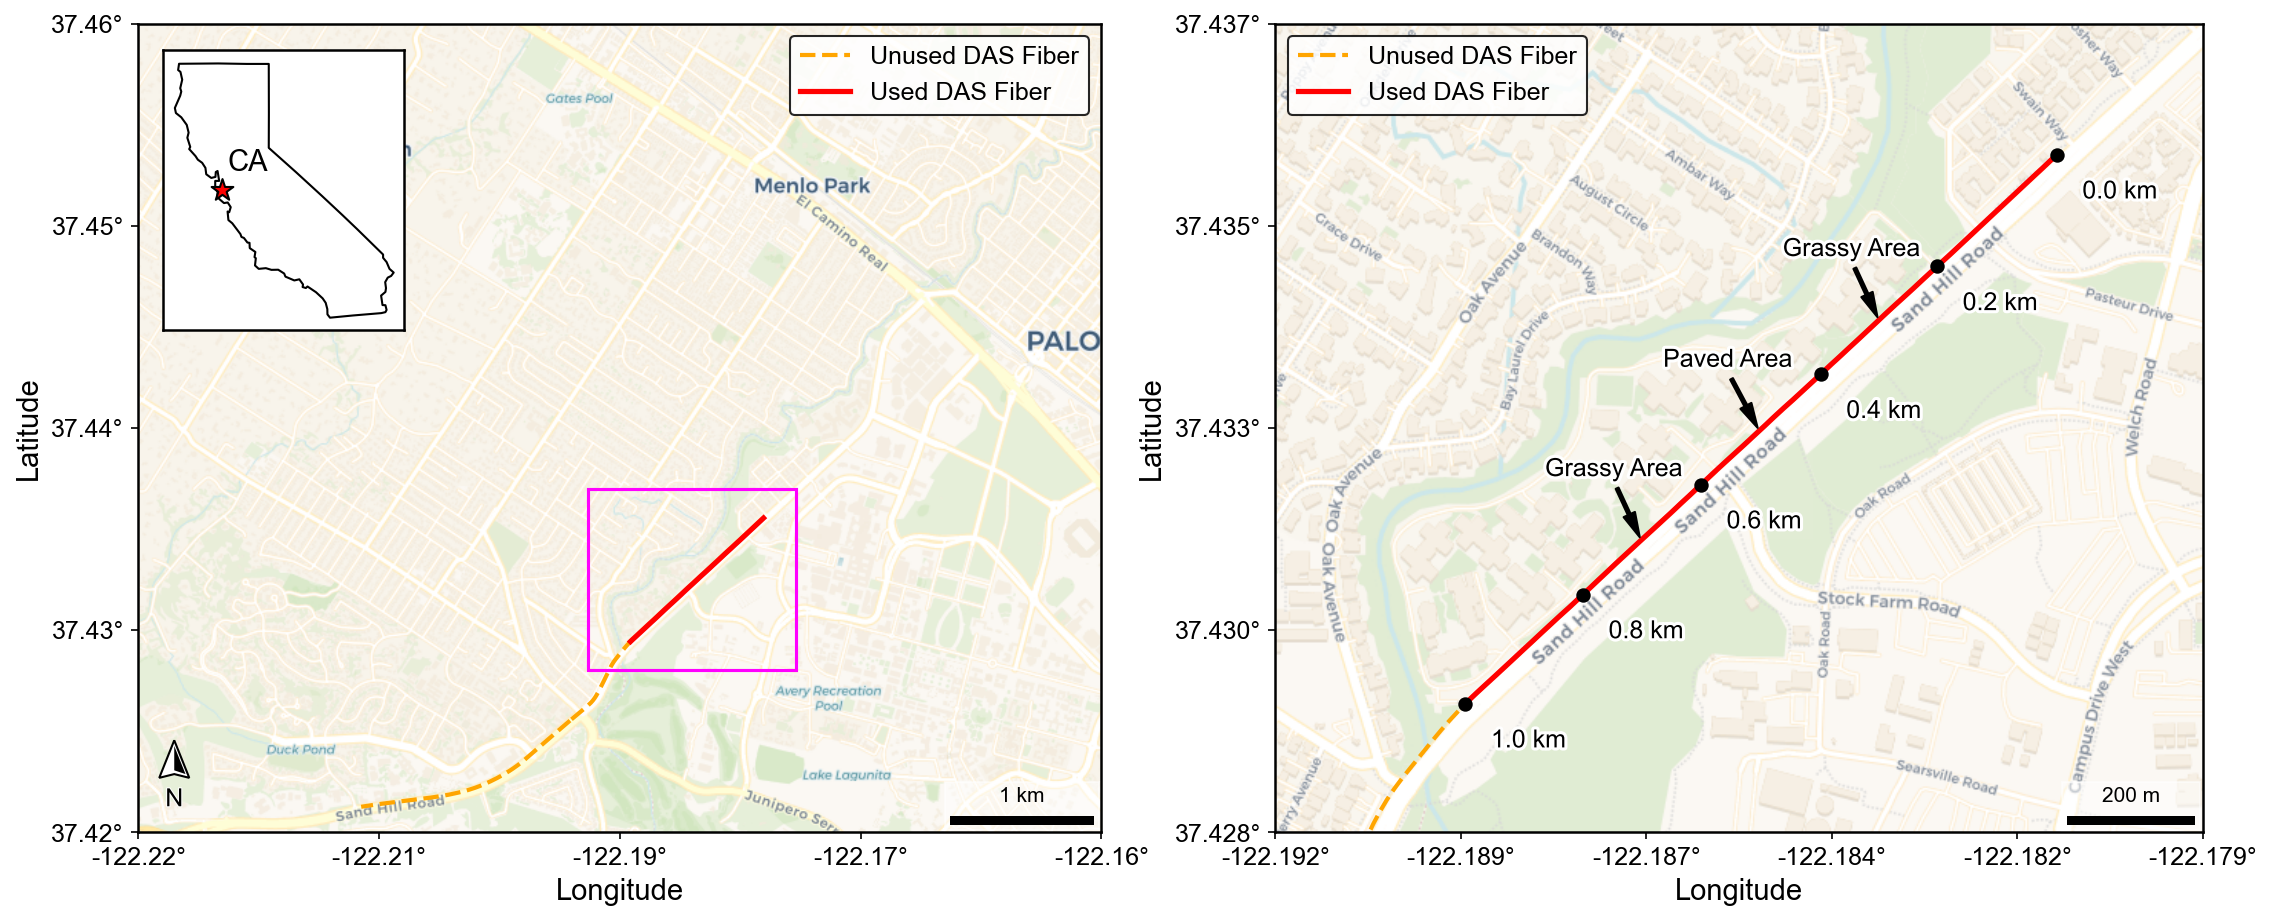

In [ ]:
fig, axes = plt. subplots(1, 2, figsize=(18, 7), dpi=150, gridspec_kw={'wspace': 0.15})

# Panel 1: Regional map (left)
# --------------------------------
ax1 = axes[0]
transformer_reg = dg.add_basemap(
    ax1, lon_min_reg, lon_max_reg, lat_min_reg, lat_max_reg, 
    attribution=False, source=ctx.providers.CartoDB.Voyager
)

full_x_reg, full_y_reg = transformer_reg.transform(das_full['long'].values, das_full['lat'].values)
used_x_reg, used_y_reg = transformer_reg.transform(das_used['long'].values, das_used['lat'].values)

ax1.plot(full_x_reg, full_y_reg, '--', c='orange', linewidth=2, label='Unused DAS Fiber')
ax1.plot(used_x_reg, used_y_reg, '-', c='red', linewidth=2.5, label='Used DAS Fiber')

# Zoom box
box_x_min, box_y_min = transformer_reg.transform(lon_min_box, lat_min_box)
box_x_max, box_y_max = transformer_reg.transform(lon_max_box, lat_max_box)
zoom_rect = patches.Rectangle(
    (box_x_min, box_y_min), box_x_max - box_x_min, box_y_max - box_y_min, 
    linewidth=1.5, edgecolor='magenta', facecolor='none', zorder=5
)
ax1.add_patch(zoom_rect)

# North arrow 
north_arrow(
    ax1, 
    location="lower left", 
    rotation={"crs": 3857, "reference": "center"}, # 3857 is the Web Mercator CRS our map uses
    fancy = True, 
    shadow = False, 
    scale = 0.25, 
    label={"position":"bottom", "text":"N", "fontsize":12},
)

# Inset map (California)
axins = inset_axes(ax1, width="25%", height="35%", loc="upper left", borderpad=1)
ca_gdf.plot(ax=axins, color='white', edgecolor='black', linewidth=1)
star_x, star_y = transformer_reg.transform((lon_min_reg+lon_max_reg)/2, (lat_min_reg+lat_max_reg)/2)
axins.scatter(star_x, star_y, marker='*', color='red', s=120, edgecolor='black', linewidths=1, zorder=5)
axins.text(0.35, 0.6, 'CA', transform=axins.transAxes, 
               fontsize=14, color='black', ha='center', va='center')

axins.set_xticks([])
axins.set_yticks([])

# Formatting left panel
dg.add_ticks(ax1, unit="degree", interval=0.01)
dg.add_scale(ax1, dx=1.0, length_fraction=0.25, location='lower right')
ax1.set_aspect('equal')

# Set legend transparency with framealpha
ax1.legend(loc='upper right', fontsize=12, framealpha=0.85, edgecolor='black')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')


# Panel 2: Zoomed map (right)
# --------------------------------
ax2 = axes[1]
transformer_zoom = dg.add_basemap(
    ax2, lon_min_box, lon_max_box, lat_min_box, lat_max_box,
    attribution=False, source=ctx.providers.CartoDB.Voyager
)

full_x_zoom, full_y_zoom = transformer_zoom.transform(das_full['long'].values, das_full['lat'].values)
used_x_zoom, used_y_zoom = transformer_zoom.transform(das_used['long'].values, das_used['lat'].values)

ax2.plot(full_x_zoom, full_y_zoom, '--', c='orange', linewidth=2, label='Unused DAS Fiber')
ax2.plot(used_x_zoom, used_y_zoom, '-', c='red', linewidth=2.5, label='Used DAS Fiber')

# Distance markers
for label_distance in range(0, 1001, 200):
    closest_index = np.abs(distances - label_distance).argmin()
    label_x = full_x_zoom[closest_index]
    label_y = full_y_zoom[closest_index]

    ax2.scatter(label_x, label_y, marker="o", s=35, c='black', zorder=4)
    ax2.text(label_x + 40, label_y - 40, f'{label_distance/1000:.1f} km', 
             fontsize=12, color='black', ha='left', va='top',
             path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# Environment annotations
idx_grassy1 = np.abs(distances - 300).argmin() 
idx_paved   = np.abs(distances - 500).argmin() 
idx_grassy2 = np.abs(distances - 700).argmin() 

annotations = [
    ("Grassy Area", idx_grassy1, -150, 100),
    ("Paved Area", idx_paved, -150, 100),
    ("Grassy Area", idx_grassy2, -150, 100)
]

for text, idx, dx, dy in annotations:
    t_x, t_y = full_x_zoom[idx], full_y_zoom[idx]
    ax2.annotate(
        text, 
        xy=(t_x, t_y),               
        xytext=(t_x + dx, t_y + dy), 
        fontsize=12,
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
        zorder=6
    )

# Formatting right panel
dg.add_ticks(ax2, unit="degree", interval=0.002) 
dg.add_scale(ax2, dx=1.0, length_fraction=0.3, location='lower right') 
ax2.set_aspect('equal')

# Set legend transparency with framealpha
ax2.legend(loc='upper left', fontsize=12, framealpha=0.85, edgecolor='black')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.savefig("../geometry/das_geo.png", dpi=300, bbox_inches='tight')
plt.show()

```bash


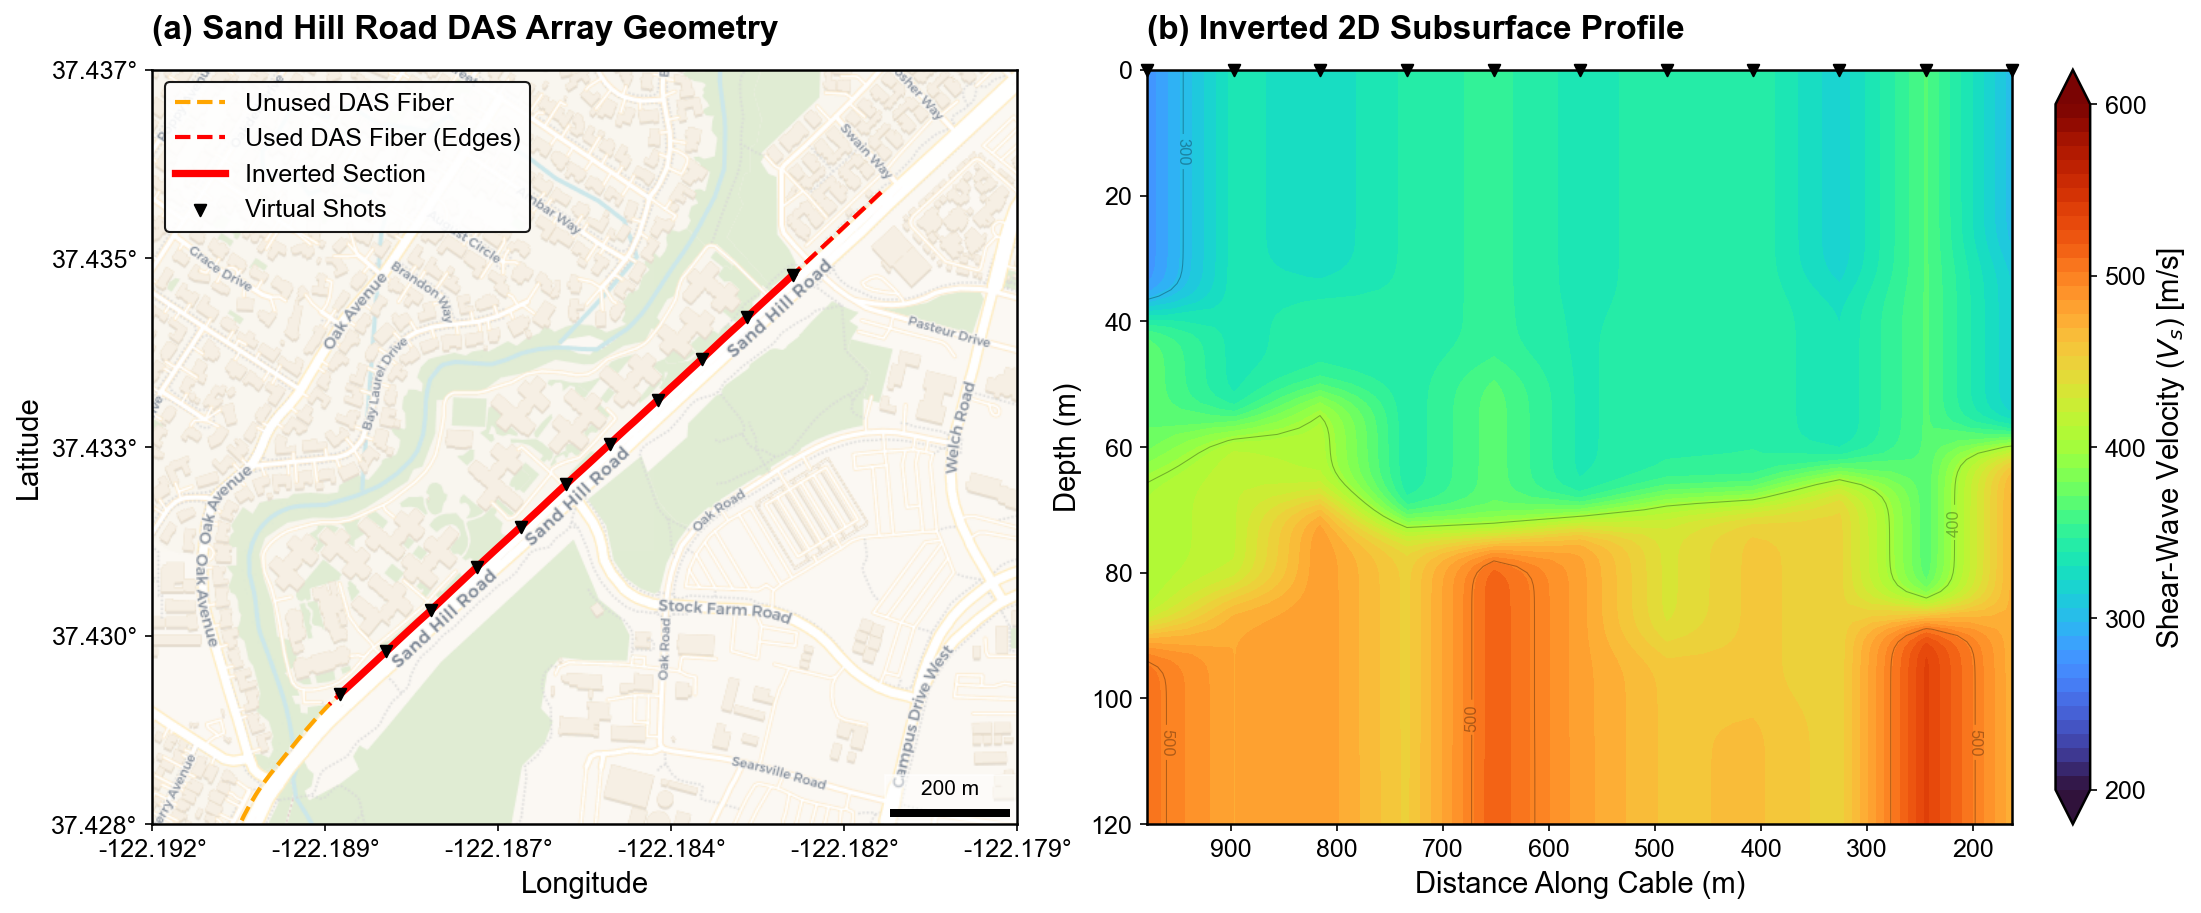

In [ ]:
# FIGURE SETUP 
fig = plt.figure(figsize=(16, 7), dpi=150)

# 1 row, 2 columns. width_ratios=[1, 1] gives them equal horizontal space
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.15)

# PANEL 1: Zoomed Map (Left)
# --------------------------------
ax1 = fig.add_subplot(gs[0]) 
transformer_zoom = dg.add_basemap(
    ax1, lon_min_box, lon_max_box, lat_min_box, lat_max_box,
    attribution=False, source=ctx.providers.CartoDB.Voyager
)

full_x_zoom, full_y_zoom = transformer_zoom.transform(das_full['long'].values, das_full['lat'].values)
used_x_zoom, used_y_zoom = transformer_zoom.transform(das_used['long'].values, das_used['lat'].values)

# 1. Unused DAS
ax1.plot(full_x_zoom, full_y_zoom, '--', c='orange', linewidth=2, label='Unused DAS Fiber')

# 2. Used DAS (Edges)
ax1.plot(used_x_zoom, used_y_zoom, '--', c='red', linewidth=2, label='Used DAS Fiber (Edges)')

# 3. Solvable / Inverted Section
start_idx = np.abs(distances - positions.min()).argmin()
end_idx = np.abs(distances - positions.max()).argmin()
ax1.plot(used_x_zoom[start_idx:end_idx+1], used_y_zoom[start_idx:end_idx+1], 
         '-', c='red', linewidth=3.5, label='Inverted Section')

# 4. Virtual Shots 
shot_x, shot_y = [], []
for p in positions:
    idx = np.abs(distances - p).argmin()
    shot_x.append(used_x_zoom[idx])
    shot_y.append(used_y_zoom[idx])
ax1.scatter(shot_x, shot_y, marker="v", s=30, c='black', zorder=5, label='Virtual Shots')

dg.add_ticks(ax1, unit="degree", interval=0.002) 
dg.add_scale(ax1, dx=1.0, length_fraction=0.25, location='lower right') 
ax1.set_aspect('equal')
ax1.legend(loc='upper left', fontsize=12, framealpha=0.9, edgecolor='black')
ax1.set_xlabel('Longitude', fontsize=14)
ax1.set_ylabel('Latitude', fontsize=14)
ax1.set_title("(a) Sand Hill Road DAS Array Geometry", loc='left', fontweight='bold', fontsize=16, pad=15)

# Calculate the precise map aspect ratio so we can copy it to the profile
x_min, y_min = transformer_zoom.transform(lon_min_box, lat_min_box)
x_max, y_max = transformer_zoom.transform(lon_max_box, lat_max_box)
map_aspect_ratio = (y_max - y_min) / (x_max - x_min)

# PANEL 2: 2D Vs Profile (Right)
# --------------------------------
ax2 = fig.add_subplot(gs[1]) 

cf = dg.plot_2d_contour_section(
    positions=positions, 
    z_grid=z_grid, 
    vs_2d_matrix=vs_matrix, 
    ax=ax2, 
    contour=True,  
    x_flip=True, 
    smooth_sigma=(3, 0)
)

ax2.set_title("(b) Inverted 2D Subsurface Profile", loc='left', fontweight='bold', fontsize=16, pad=15)
ax2.set_xlabel("Distance Along Cable (m)", fontsize=14)
ax2.set_ylabel("Depth (m)", fontsize=14)

# Virtual Shots on profile

ax2.scatter(positions, np.zeros_like(positions), marker='v', color='black', 
            s=30, clip_on=False, label='Virtual Shots', zorder=10)

# ------------------------------------------------------------------------------
# THE ALIGNMENT TRICK: Force the profile to have the exact same box shape as the map
ax2.set_box_aspect(map_aspect_ratio)
# ------------------------------------------------------------------------------

# FLOATING COLORBAR
# Keep the colorbar attached outside the newly perfectly sized box
cax = inset_axes(ax2, width="4%", height="100%", loc='center left', 
                 bbox_to_anchor=(1.05, 0., 1, 1), bbox_transform=ax2.transAxes, borderpad=0)

tick_levels = np.arange(200, 600 + 100, 100) 
cbar = fig.colorbar(cf, cax=cax, ticks=tick_levels)
cbar.set_label('Shear-Wave Velocity ($V_s$) [m/s]', fontsize=14)

plt.savefig("../geometry/das_profile.png", dpi=300, bbox_inches='tight')
plt.show()